<a href="https://colab.research.google.com/github/jovo999/marvel/blob/main/marvel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from collections import Counter

In [2]:
df = pd.read_csv('marvel.csv')
df

,Character,Real Name,Affiliation,Powers,Role,Power Level
0,iron man,Tony Stark,Avengers,"Powered Armor, Genius-level intellect",Hero,Low
1,captain america,Steve Rogers,Avengers,"Super Soldier, Enhanced strength",Hero,Low
2,thor,Thor Odinson,Avengers,"God of Thunder, Weather manipulation",Hero,Low
3,black widow,Natasha Romanoff,Avengers,"Superhuman strength, Espionage",Hero,Low
4,hulk,Bruce Banner,Avengers,"Superhuman strength, Gamma Radiation",Hero,Low
5,spider-man,Peter Parker,Avengers,"Spider sense, Wall crawling",Hero,Low
6,wolverine,James Howlett,X-Men,"Regeneration, Adamantium claws",Hero,Low
7,deadpool,Wade Wilson,X-Force,"Regeneration, Skilled hand-to-hand combatant",Antihero,Low
8,black panther,T’Challa,Avengers,"Superhuman strength, Vibranium suit",Hero,Low
9,doctor strange,Stephen Strange,Avengers,"Sorcery, Magic",Hero,Low


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45 entries, 0 to 44
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Character    45 non-null     object
 1   Real Name    45 non-null     object
 2   Affiliation  45 non-null     object
 3   Powers       45 non-null     object
 4   Role         45 non-null     object
 5   Power Level  45 non-null     object
dtypes: object(6)
memory usage: 2.2+ KB


In [4]:
df['Role'].value_counts()

,count
Role,
Hero,35
Villain,8
Antihero,2


In [5]:
df['Affiliation'].value_counts()

,count
Affiliation,
Avengers,23
Defenders,4
Sinister Six,4
Fantastic Four,4
Villain,3
Guardians of the Galaxy,3
X-Men,1
X-Force,1
Inhumans,1


In [6]:
def rael_power(power):
  if power['Affiliation'] == 'Avengers' and power['Role'] == 'Hero':
    return 'high'
  elif power['Affiliation'] == 'Avengers' and power['Role'] == 'Villian':
    return 'madime'
  elif power['Affiliation'] == 'X-Men' and power['Role'] == 'Hero':
    return 'high'
  elif power['Affiliation'] == 'Fantastic Four' and power['Role'] == 'Hero':
    return 'madime'
  elif power['Role'] == 'Antihero':
    return 'high'
  elif power['Role'] == 'Villain':
    return 'madime'
  else:
    return 'low'

df['Power Level'] = df.apply(rael_power, axis=1)
df

,Character,Real Name,Affiliation,Powers,Role,Power Level
0,iron man,Tony Stark,Avengers,"Powered Armor, Genius-level intellect",Hero,high
1,captain america,Steve Rogers,Avengers,"Super Soldier, Enhanced strength",Hero,high
2,thor,Thor Odinson,Avengers,"God of Thunder, Weather manipulation",Hero,high
3,black widow,Natasha Romanoff,Avengers,"Superhuman strength, Espionage",Hero,high
4,hulk,Bruce Banner,Avengers,"Superhuman strength, Gamma Radiation",Hero,high
5,spider-man,Peter Parker,Avengers,"Spider sense, Wall crawling",Hero,high
6,wolverine,James Howlett,X-Men,"Regeneration, Adamantium claws",Hero,high
7,deadpool,Wade Wilson,X-Force,"Regeneration, Skilled hand-to-hand combatant",Antihero,high
8,black panther,T’Challa,Avengers,"Superhuman strength, Vibranium suit",Hero,high
9,doctor strange,Stephen Strange,Avengers,"Sorcery, Magic",Hero,high


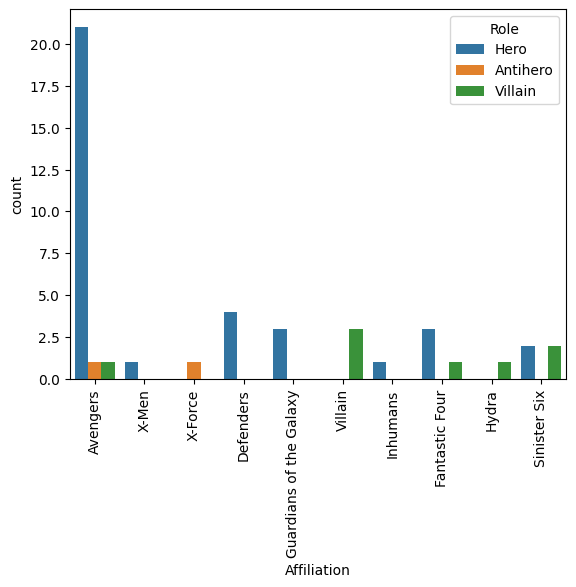

In [7]:
sns.countplot(data=df, x='Affiliation' , hue='Role' )
plt.xticks(rotation=90)
plt.show()

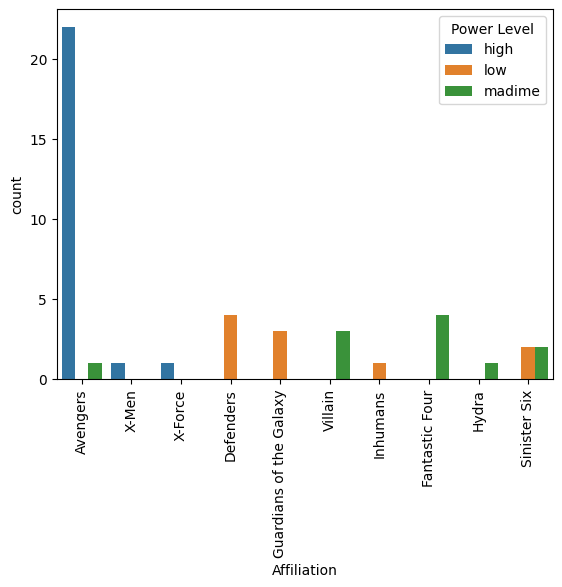

In [8]:
sns.countplot(data=df, x='Affiliation' , hue='Power Level' )
plt.xticks(rotation=90)
plt.show()

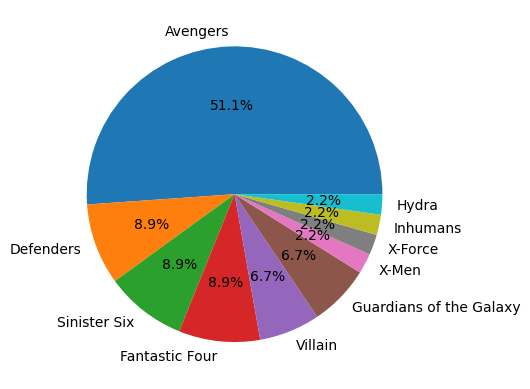

In [9]:
plt.pie(df['Affiliation'].value_counts(), labels=df['Affiliation'].value_counts().index, autopct='%1.1f%%')
plt.show()

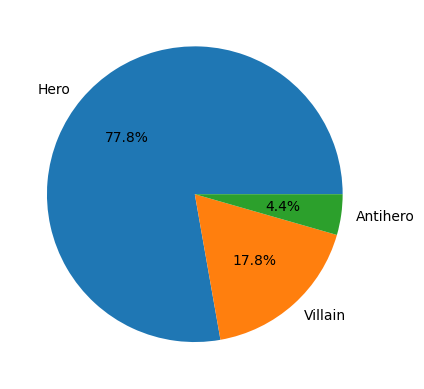

In [10]:
plt.pie(df['Role'].value_counts(), labels=df['Role'].value_counts().index, autopct='%1.1f%%')
plt.show()

In [11]:
sns.set_palette("deep")

In [12]:
powers_list = []
for powers in df['Powers']:
    powers_split = [power.strip() for power in powers.split(',')]
    powers_list.extend(powers_split)

In [13]:
power_counts = Counter(powers_list)
power_df = pd.DataFrame.from_dict(power_counts, orient='index', columns=['Count']).reset_index()
power_df = power_df.rename(columns={'index': 'Power'}).sort_values(by='Count', ascending=False)

In [14]:
powers_expanded = []
for idx, row in df.iterrows():
    powers = [power.strip() for power in row['Powers'].split(',')]
    for power in powers:
        powers_expanded.append({'Role': row['Role'], 'Power': power})
powers_role_df = pd.DataFrame(powers_expanded)

In [15]:
top_powers = power_df.head(5)['Power'].tolist()
powers_role_filtered = powers_role_df[powers_role_df['Power'].isin(top_powers)]

<ipython-input-16-3dfcbdfce3fd>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=power_df.head(10), x='Count', y='Power', palette='Blues_r')


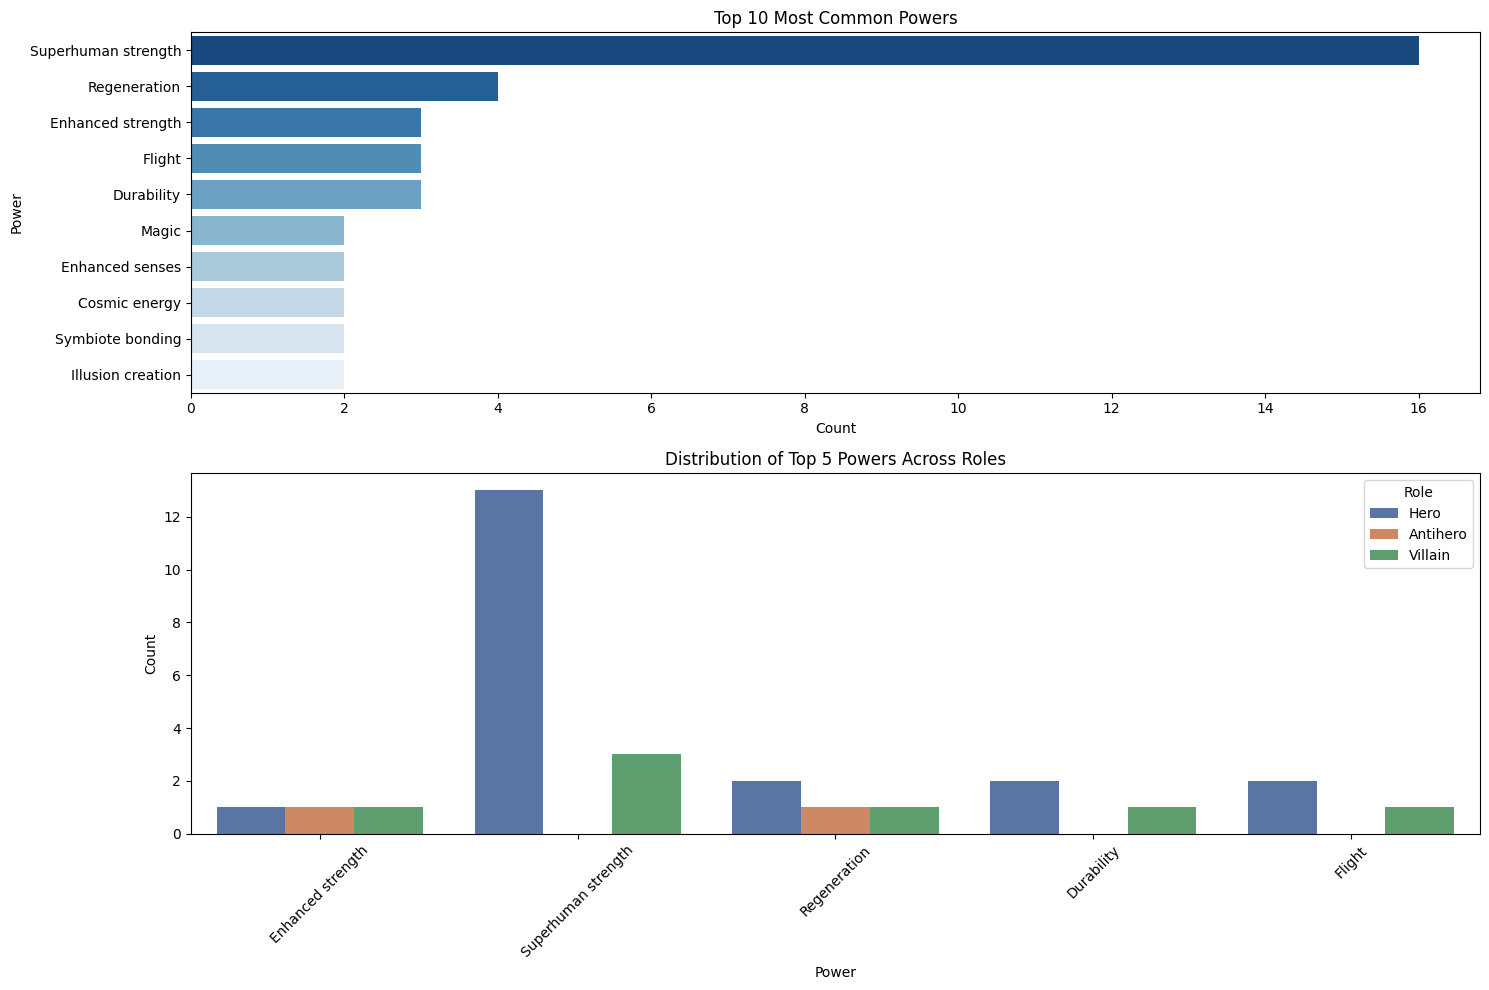

In [16]:
fig = plt.figure(figsize=(15, 10))

plt.subplot(2, 1, 1)
sns.barplot(data=power_df.head(10), x='Count', y='Power', palette='Blues_r')
plt.title('Top 10 Most Common Powers')
plt.xlabel('Count')
plt.ylabel('Power')

plt.subplot(2, 1, 2)
sns.countplot(data=powers_role_filtered, x='Power', hue='Role', palette='deep')
plt.title('Distribution of Top 5 Powers Across Roles')
plt.xlabel('Power')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Role')

plt.tight_layout()
plt.savefig('section3_powers_distribution.png')
plt.show()